# Trabalhando com Dados da Pandemia

Este notebook avalia seis métodos de imputação para preencher a lacuna da COVID-19 na série temporal de chegadas de turistas ao Brasil.

**Abordagem:** selecionar múltiplas janelas pré-COVID não sobrepostas, mascarar cada uma para simular uma lacuna, ajustar/aplicar cada método usando apenas os dados *antes* (e onde aplicável *depois*) da janela mascarada, e medir o erro de reconstrução em relação à verdade.

**Métodos comparados:**
1. Interpolação linear (baseada em tempo)
2. STL + PCHIP — decomposição STL ajustada nos dados pré-lacuna; componente sazonal projetado para frente na lacuna; interpolação PCHIP aplicada apenas à tendência, depois o sazonal é somado de volta
3. Interpolação Spline (ordem=3)
4. Auto ARIMA — SARIMAX forward ajustado apenas nos dados pré-lacuna
5. Auto ARIMA (reverso) — SARIMAX ajustado nos dados pós-lacuna *invertidos*, previsões revertidas à ordem cronológica
6. Combinação ARIMA — média ponderada com decaimento linear das previsões forward e backward

**Métricas:**
- MAE, RMSE, MAPE — erro de reconstrução pontual vs. verdade
- **Lacuna de variância** — `|var(verdadeiro) − var(imputado)|` na lacuna, para detectar métodos que produzem reconstruções suavizadas (ou espinhosas) demais
- **RMSE / MAPE ARIMA downstream (sem vazamento)** — para cada método, ajusta um auto ARIMA em `[gap_start − 24m, 2019-06-30]` e avalia a acurácia de previsão 6 meses à frente em `2019-07-01 → 2019-12-31`

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pmdarima import auto_arima
from statsmodels.tsa.seasonal import STL

warnings.filterwarnings('ignore')

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')

COVID_START = pd.Timestamp('2020-01-01')
COVID_END = pd.Timestamp('2021-12-31')

sns.set_palette('colorblind')

## Importação de Dados

In [2]:
df = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, 'train_ptbr.parquet'))
df = df.set_index('date')

monthly_df = df[['arrival_count']].resample('ME').sum()

print(
    f'Intervalo da série : {monthly_df.index.min().date()} → {monthly_df.index.max().date()}'
)
print(f'Total de meses : {len(monthly_df)}')
monthly_df.head()

Intervalo da série : 1989-01-31 → 2024-12-31
Total de meses : 432


,arrival_count
date,
1989-01-31,291566.0
1989-02-28,197348.0
1989-03-31,149001.0
1989-04-30,84867.0
1989-05-31,69293.0


## Benchmark de Imputação

### Janelas de Teste

Treze janelas pré-COVID de comprimentos variados (6 → 36 meses) abrangendo 1995 → 2015. Todas as janelas são delimitadas para que a janela de teste do ARIMA downstream fique dentro da região pré-COVID.

O benchmark se divide naturalmente em dois grupos:
- **W0 → W6** — janelas antigas, não sobrepostas, distribuídas por diferentes regimes históricos.
- **W7 → W12** — teste de estresse em anos recentes: seis janelas de comprimento decrescente (36m → 6m) terminando em 2015-12-31.

A métrica **ARIMA downstream** usa geometria fixa por janela, ancorada em cada lacuna:

| segmento              | meses | offset da lacuna |
|-----------------------|-------|------------------|
| DS treino (pré-lacuna)   | 24 | gap_start − 24m … gap_start − 1m |
| DS lacuna (imputada)     | 6–36 | gap_start … gap_end (por janela)  |
| DS treino (pós-lacuna)   | 36 | gap_end + 1m … gap_end + 36m     |
| DS teste (real)          | 12 | gap_end + 37m … gap_end + 48m    |

In [3]:
WINDOWS = [
    # Janelas antigas, bem espaçadas por diferentes regimes históricos
    ('W0', pd.Timestamp('1995-01-31'), pd.Timestamp('1995-06-30')),  # 6m
    ('W1', pd.Timestamp('1998-01-31'), pd.Timestamp('1998-12-31')),  # 12m
    ('W2', pd.Timestamp('2001-01-31'), pd.Timestamp('2002-06-30')),  # 18m
    ('W3', pd.Timestamp('2004-01-31'), pd.Timestamp('2006-12-31')),  # 36m
    ('W4', pd.Timestamp('2008-01-31'), pd.Timestamp('2009-12-31')),  # 24m
    ('W5', pd.Timestamp('2010-01-31'), pd.Timestamp('2011-12-31')),  # 24m
    ('W6', pd.Timestamp('2012-01-31'), pd.Timestamp('2013-12-31')),  # 24m
    ('W7', pd.Timestamp('2013-01-31'), pd.Timestamp('2015-12-31')),  # 36m
    ('W8', pd.Timestamp('2013-07-31'), pd.Timestamp('2015-12-31')),  # 30m
    ('W9', pd.Timestamp('2014-01-31'), pd.Timestamp('2015-12-31')),  # 24m
    ('W10', pd.Timestamp('2014-07-31'), pd.Timestamp('2015-12-31')),  # 18m
    ('W11', pd.Timestamp('2015-01-31'), pd.Timestamp('2015-12-31')),  # 12m
    ('W12', pd.Timestamp('2015-07-31'), pd.Timestamp('2015-12-31')),  # 6m
]

RANDOM_STATE = 42  # para reprodutibilidade da busca do auto_arima

for name, start, end in WINDOWS:
    n = monthly_df.loc[start:end].shape[0]
    print(f'{name}: {start.date()} → {end.date()} ({n} meses)')

W0: 1995-01-31 → 1995-06-30 (6 meses)
W1: 1998-01-31 → 1998-12-31 (12 meses)
W2: 2001-01-31 → 2002-06-30 (18 meses)
W3: 2004-01-31 → 2006-12-31 (36 meses)
W4: 2008-01-31 → 2009-12-31 (24 meses)
W5: 2010-01-31 → 2011-12-31 (24 meses)
W6: 2012-01-31 → 2013-12-31 (24 meses)
W7: 2013-01-31 → 2015-12-31 (36 meses)
W8: 2013-07-31 → 2015-12-31 (30 meses)
W9: 2014-01-31 → 2015-12-31 (24 meses)
W10: 2014-07-31 → 2015-12-31 (18 meses)
W11: 2015-01-31 → 2015-12-31 (12 meses)
W12: 2015-07-31 → 2015-12-31 (6 meses)


### Funções Auxiliares

In [4]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def apply_linear(series_with_nan):
    return series_with_nan.interpolate(method='time').clip(lower=0)


def apply_stl_pchip(series_with_nan, gap_mask, pre_gap_end):
    """STL nos dados pré-lacuna; projeta sazonal para frente; PCHIP na tendência."""
    pre_gap = series_with_nan[series_with_nan.index <= pre_gap_end].dropna()

    stl = STL(pre_gap, period=12, seasonal=13, robust=True)
    stl_res = stl.fit()

    # Replica o padrão sazonal do último ano completo sobre a lacuna
    n_gap = int(gap_mask.sum())
    seasonal_pattern = stl_res.seasonal[-12:].values
    projected_seasonal = np.tile(seasonal_pattern, n_gap // 12 + 1)[:n_gap]

    # Interpola tendência em toda a série (lacuna como NaN)
    trend_interp = series_with_nan.interpolate(method='pchip')

    result = series_with_nan.copy()
    result[gap_mask] = (trend_interp[gap_mask].values + projected_seasonal).clip(min=0)
    return result


def apply_spline(series_with_nan):
    return series_with_nan.interpolate(method='spline', order=3).clip(lower=0)


def apply_auto_arima(series_with_nan, gap_mask, pre_gap_end):
    """Ajusta SARIMAX nos dados estritamente antes da lacuna, prevê na lacuna."""
    pre_gap = series_with_nan[series_with_nan.index <= pre_gap_end].dropna()
    n_gap = int(gap_mask.sum())
    model = auto_arima(
        pre_gap,
        seasonal=True,
        m=12,
        stepwise=False,
        n_jobs=-1,
        max_p=2,
        max_q=2,
        max_P=2,
        max_Q=2,
        d=1,
        D=0,
        information_criterion='aicc',
        out_of_sample_size=12,
        error_action='ignore',
        suppress_warnings=True,
        random_state=RANDOM_STATE,
    )
    forecast = np.asarray(model.predict(n_periods=n_gap))
    result = series_with_nan.copy()
    result[gap_mask] = np.clip(forecast, 0, None)
    return result, model, forecast


def apply_auto_arima_bwd(series_with_nan, gap_mask, post_gap_start, post_gap_end):
    """Ajusta SARIMAX nos dados pós-lacuna *invertidos*, prevê de trás para frente.

    A fatia pós-lacuna é invertida para array numpy (evita incompatibilidade de índice
    durante o ajuste); o modelo aprende tendência/sazonalidade movendo-se para trás no
    tempo; a previsão é então invertida para se alinhar cronologicamente com a lacuna.
    """
    post_gap = series_with_nan[
        (series_with_nan.index >= post_gap_start)
        & (series_with_nan.index <= post_gap_end)
    ].dropna()
    n_gap = int(gap_mask.sum())

    reversed_arr = post_gap.values[::-1]
    model = auto_arima(
        reversed_arr,
        seasonal=True,
        m=12,
        stepwise=False,
        n_jobs=-1,
        max_p=2,
        max_q=2,
        max_P=2,
        max_Q=2,
        d=1,
        D=0,
        information_criterion='aicc',
        out_of_sample_size=12,
        error_action='ignore',
        suppress_warnings=True,
        random_state=RANDOM_STATE,
    )
    forecast_bwd_raw = np.asarray(model.predict(n_periods=n_gap))
    forecast_bwd = forecast_bwd_raw[::-1]  # restaura ordem cronológica

    result = series_with_nan.copy()
    result[gap_mask] = np.clip(forecast_bwd, 0, None)
    return result, model, forecast_bwd


def apply_arima_blend(series_with_nan, gap_mask, forecast_fwd, forecast_bwd):
    """Média ponderada com decaimento linear: 100% forward no início → 100% backward no fim."""
    n_gap = int(gap_mask.sum())
    w = np.linspace(1.0, 0.0, n_gap)
    imputed = w * forecast_fwd + (1.0 - w) * forecast_bwd

    result = series_with_nan.copy()
    result[gap_mask] = np.clip(imputed, 0, None)
    return result


# ---- Métrica ARIMA downstream (geometria sem vazamento por janela) ----
N_DS_PRE = 24
N_DS_POST = 36
N_DS_TEST = 12


def ds_train_end_for(gap_end, n_post=N_DS_POST):
    """Último mês incluído no treino downstream para uma dada lacuna."""
    return gap_end + pd.DateOffset(months=n_post)


def _fit_predict_auto_arima(train_values, n_periods):
    model = auto_arima(
        train_values,
        seasonal=True,
        m=12,
        stepwise=False,
        n_jobs=-1,
        max_p=2,
        max_q=2,
        max_P=2,
        max_Q=2,
        d=1,
        D=0,
        information_criterion='aicc',
        out_of_sample_size=12,
        error_action='ignore',
        suppress_warnings=True,
        random_state=RANDOM_STATE,
    )
    return np.asarray(model.predict(n_periods=n_periods))


def downstream_arima_scores(
    full_series,
    imputed_series,
    gap_start,
    gap_end,
    n_pre=N_DS_PRE,
    n_post=N_DS_POST,
    n_test=N_DS_TEST,
    data_cutoff=None,
):
    """Treina auto_arima com imputação sem vazamento e pontua a previsão."""
    train_start = gap_start - pd.DateOffset(months=n_pre)
    train_end = gap_end + pd.DateOffset(months=n_post)
    test_end = train_end + pd.DateOffset(months=n_test)

    if data_cutoff is not None and test_end > data_cutoff:
        return np.nan, np.nan

    train = imputed_series.loc[train_start:train_end].copy()
    pre_idx = train.index[train.index < gap_start]
    post_idx = train.index[train.index > gap_end]
    train.loc[pre_idx] = full_series.loc[pre_idx]
    train.loc[post_idx] = full_series.loc[post_idx]

    test = full_series.loc[
        (full_series.index > train_end) & (full_series.index <= test_end)
    ]
    if len(test) < n_test or train.isna().any():
        return np.nan, np.nan

    forecast = _fit_predict_auto_arima(train.values, n_test)
    return rmse(test.values, forecast), mape(test.values, forecast)


def oracle_arima_scores(
    full_series,
    gap_start,
    gap_end,
    n_pre=N_DS_PRE,
    n_post=N_DS_POST,
    n_test=N_DS_TEST,
    data_cutoff=None,
):
    """Mesma geometria de treino/teste, mas com os valores *reais* da lacuna."""
    train_start = gap_start - pd.DateOffset(months=n_pre)
    train_end = gap_end + pd.DateOffset(months=n_post)
    test_end = train_end + pd.DateOffset(months=n_test)

    if data_cutoff is not None and test_end > data_cutoff:
        return np.nan, np.nan

    train = full_series.loc[train_start:train_end]
    test = full_series.loc[
        (full_series.index > train_end) & (full_series.index <= test_end)
    ]
    if len(test) < n_test:
        return np.nan, np.nan

    forecast = _fit_predict_auto_arima(train.values, n_test)
    return rmse(test.values, forecast), mape(test.values, forecast)


METHOD_STYLES = {
    'Linear': ('steelblue', '-'),
    'STL + PCHIP': ('darkorange', '-'),
    'Spline': ('seagreen', '-'),
    'Auto ARIMA (fwd)': ('mediumpurple', '-'),
    'Auto ARIMA (bwd)': ('crimson', '-'),
    'Combinação ARIMA': ('teal', '-'),
}

### Executar Benchmark em Todas as Janelas

In [5]:
# ---- Auxiliares de formatação do console ----
def _fmt_int(width):
    return lambda v: f'{v:>{width},.0f}'


def _fmt_int_na(width):
    """Inteiro alinhado à direita; valores não finitos aparecem como 'n/d'."""
    return lambda v: f'{v:>{width},.0f}' if np.isfinite(v) else f'{"n/d":>{width}}'


def _fmt_ratio(width):
    return lambda v: f'{v:>{width}.3f}'


def _fmt_pct(width):
    """Porcentagem alinhada à direita; valores não finitos aparecem como 'n/d'."""
    return lambda v: f'{v:>{width - 1}.2f}%' if np.isfinite(v) else f'{"n/d":>{width}}'


METRIC_COLUMNS = [
    ('Método', '<17', lambda v: f'{v:<17}'),
    ('MAE', '>10', _fmt_int(10)),
    ('RMSE', '>10', _fmt_int(10)),
    ('MAPE', '>7', _fmt_pct(7)),
    ('var_orig', '>14', _fmt_int(14)),
    ('var_pred', '>14', _fmt_int(14)),
    ('var_ratio', '>10', _fmt_ratio(10)),
    ('DS-RMSE', '>10', _fmt_int_na(10)),
    ('DS-MAPE', '>8', _fmt_pct(8)),
]


def print_banner(title):
    """Imprime cabeçalho de seção de janela."""
    rule = '=' * 55
    print(f'\n{rule}\n  {title}\n{rule}')


def metric_header():
    cells = (f'{label:{align}}' for label, align, _ in METRIC_COLUMNS)
    return '  ' + '  '.join(cells)


def metric_row(values):
    """Renderiza uma linha; `values` alinha posicionalmente com METRIC_COLUMNS."""
    cells = (fmt(v) for (_, _, fmt), v in zip(METRIC_COLUMNS, values))
    return '  ' + '  '.join(cells)


print(f'{"=" * 75}')
print('  METODOLOGIA DO BENCHMARK')
print(f'{"=" * 75}')
print(
    """
  Para cada janela pré-COVID mascaramos a lacuna, imputamos com seis métodos e
  avaliamos de duas formas:

  Métricas de RECONSTRUÇÃO  - quão próxima a imputação está dos valores reais.
    MAE / RMSE / MAPE   erro pontual vs. verdade ao longo da lacuna.
    var_orig / var_pred variância da lacuna real vs. imputada.
    var_ratio           = var_pred / var_orig.  1,0 = ideal; <1 super-suavizado,
                          >1 super-espinhoso.

  Métricas DOWNSTREAM (DS) - a imputação ajuda um modelo a prever o FUTURO?
    Ajusta auto-ARIMA em  [24m real pré-lacuna] + [lacuna imputada] + [36m real pós-lacuna],
    depois prevê 12 meses e pontua contra a série real.
    DS-RMSE / DS-MAPE   erro dessa previsão de 12 meses.
    'n/d' = a janela de teste DS cairia dentro da COVID, métrica ignorada.

  Linha de base ORACLE - mesma geometria DS mas com os valores REAIS da lacuna.
    É a melhor pontuação DS que qualquer imputação poderia alcançar.
"""
)

records = []
window_results = {}  # armazena séries imputadas por janela para visualização

# Limita dados pós-lacuna de treino antes da pandemia para o modelo backward
POST_GAP_CUTOFF = COVID_START - pd.Timedelta(days=1)

for win_name, gap_start, gap_end in WINDOWS:
    print_banner(f'{win_name}: {gap_start.date()} → {gap_end.date()}')

    gap_mask = (monthly_df.index >= gap_start) & (monthly_df.index <= gap_end)
    truth = monthly_df.loc[gap_mask, 'arrival_count'].values
    truth_var = float(np.var(truth))

    masked = monthly_df['arrival_count'].copy()
    masked[gap_mask] = np.nan

    # Limites de treinamento
    pre_gap_start = monthly_df.index[0]
    pre_gap_end = monthly_df[monthly_df.index < gap_start].index[-1]
    post_gap_start = monthly_df[monthly_df.index > gap_end].index[0]
    post_gap_end = POST_GAP_CUTOFF
    n_pre = monthly_df.loc[pre_gap_start:pre_gap_end].shape[0]
    n_post = monthly_df.loc[post_gap_start:post_gap_end].shape[0]

    # Geometria downstream por janela
    ds_train_end = ds_train_end_for(gap_end)
    ds_test_end = ds_train_end + pd.DateOffset(months=N_DS_TEST)
    ds_in_pre_covid = ds_test_end <= POST_GAP_CUTOFF
    ds_test_start = ds_train_end + pd.DateOffset(days=1)
    ds_status = '' if ds_in_pre_covid else 'teste entraria na COVID — métrica N/D'

    print(
        f'  Período de treino pré-lacuna: {pre_gap_start.date()} → {pre_gap_end.date()} ({n_pre} meses)'
    )
    print(
        f'  Período de treino pós-lacuna: {post_gap_start.date()} → {post_gap_end.date()} ({n_post} meses)'
    )
    print(
        f'  Geometria downstream:    treino termina {ds_train_end.date()}  |  '
        f'teste {ds_test_start.date()} → {ds_test_end.date()}  '
        f'({N_DS_PRE}m pré + {N_DS_POST}m pós + {N_DS_TEST}m teste){ds_status}'
    )
    print(f'  Variância da verdade:  {truth_var:,.0f}')

    # ---- Imputações para métricas de reconstrução ----
    s_linear = apply_linear(masked)
    pred_linear = s_linear[gap_mask].values

    s_stl_pchip = apply_stl_pchip(masked, gap_mask, pre_gap_end)
    pred_stl_pchip = s_stl_pchip[gap_mask].values

    s_spline = apply_spline(masked)
    pred_spline = s_spline[gap_mask].values

    s_arima_fwd, arima_fwd_model, forecast_fwd = apply_auto_arima(
        masked, gap_mask, pre_gap_end
    )
    pred_arima_fwd = s_arima_fwd[gap_mask].values
    print(
        f'  Ordem ARIMA fwd:        {arima_fwd_model.order} x {arima_fwd_model.seasonal_order}'
    )

    s_arima_bwd, arima_bwd_model, forecast_bwd = apply_auto_arima_bwd(
        masked, gap_mask, post_gap_start, post_gap_end
    )
    pred_arima_bwd = s_arima_bwd[gap_mask].values
    print(
        f'  Ordem ARIMA bwd:        {arima_bwd_model.order} x {arima_bwd_model.seasonal_order}'
    )

    s_arima_blend = apply_arima_blend(masked, gap_mask, forecast_fwd, forecast_bwd)
    pred_arima_blend = s_arima_blend[gap_mask].values

    # ---- Imputações sem vazamento para métrica downstream ----
    if ds_in_pre_covid:
        masked_lf = masked.copy()
        masked_lf.loc[masked_lf.index > ds_train_end] = np.nan

        s_spline_lf = apply_spline(masked_lf)
        _, _, forecast_bwd_lf = apply_auto_arima_bwd(
            masked_lf, gap_mask, post_gap_start, ds_train_end
        )
        s_arima_bwd_lf = masked.copy()
        s_arima_bwd_lf[gap_mask] = np.clip(forecast_bwd_lf, 0, None)
        s_arima_blend_lf = apply_arima_blend(
            masked, gap_mask, forecast_fwd, forecast_bwd_lf
        )
    else:
        s_spline_lf = s_arima_bwd_lf = s_arima_blend_lf = None

    # Armazena séries imputadas para visualização
    window_results[win_name] = {
        'gap_mask': gap_mask,
        'Linear': s_linear,
        'STL + PCHIP': s_stl_pchip,
        'Spline': s_spline,
        'Auto ARIMA (fwd)': s_arima_fwd,
        'Auto ARIMA (bwd)': s_arima_bwd,
        'Combinação ARIMA': s_arima_blend,
    }

    # ---- Linha de base oracle ----
    oracle_rmse, oracle_mape = oracle_arima_scores(
        monthly_df['arrival_count'], gap_start, gap_end, data_cutoff=POST_GAP_CUTOFF
    )
    if np.isfinite(oracle_rmse):
        print(
            f'  Linha de base oracle (lacuna real)        '
            f'DS-RMSE={_fmt_int_na(10)(oracle_rmse)}  DS-MAPE={_fmt_pct(7)(oracle_mape)}'
        )
    else:
        print('  Linha de base oracle (lacuna real)        N/D')

    # ---- Métricas por método ----
    method_preds = [
        ('Linear', pred_linear, s_linear),
        ('STL + PCHIP', pred_stl_pchip, s_stl_pchip),
        ('Spline', pred_spline, s_spline_lf),
        ('Auto ARIMA (fwd)', pred_arima_fwd, s_arima_fwd),
        ('Auto ARIMA (bwd)', pred_arima_bwd, s_arima_bwd_lf),
        ('Combinação ARIMA', pred_arima_blend, s_arima_blend_lf),
    ]

    print('\n' + metric_header())
    for method_name, pred, s_imputed_lf in method_preds:
        mae_v = mae(truth, pred)
        rmse_v = rmse(truth, pred)
        mape_v = mape(truth, pred)
        pred_var = float(np.var(pred))
        var_ratio = pred_var / truth_var if truth_var > 0 else np.nan

        if s_imputed_lf is not None:
            ds_rmse, ds_mape = downstream_arima_scores(
                monthly_df['arrival_count'],
                s_imputed_lf,
                gap_start,
                gap_end,
                data_cutoff=POST_GAP_CUTOFF,
            )
        else:
            ds_rmse, ds_mape = np.nan, np.nan

        records.append({
            'Janela': win_name,
            'Método': method_name,
            'MAE': mae_v,
            'RMSE': rmse_v,
            'MAPE': mape_v,
            'OrigVar': truth_var,
            'PredVar': pred_var,
            'VarRatio': var_ratio,
            'DownstreamRMSE': ds_rmse,
            'DownstreamMAPE': ds_mape,
            'OracleRMSE': oracle_rmse,
            'OracleMAPE': oracle_mape,
        })
        print(
            metric_row([
                method_name,
                mae_v,
                rmse_v,
                mape_v,
                truth_var,
                pred_var,
                var_ratio,
                ds_rmse,
                ds_mape,
            ])
        )

results_df = pd.DataFrame(records)

  METODOLOGIA DO BENCHMARK

  Para cada janela pré-COVID mascaramos a lacuna, imputamos com seis métodos e
  avaliamos de duas formas:

  Métricas de RECONSTRUÇÃO  - quão próxima a imputação está dos valores reais.
    MAE / RMSE / MAPE   erro pontual vs. verdade ao longo da lacuna.
    var_orig / var_pred variância da lacuna real vs. imputada.
    var_ratio           = var_pred / var_orig.  1,0 = ideal; <1 super-suavizado,
                          >1 super-espinhoso.

  Métricas DOWNSTREAM (DS) - a imputação ajuda um modelo a prever o FUTURO?
    Ajusta auto-ARIMA em   real pré-lacuna] + [lacuna imputada] +  real pós-lacuna],
    depois prevê 12 meses e pontua contra a série real.
    DS-RMSE / DS-MAPE   erro dessa previsão de 12 meses.
    'n/d' = a janela de teste DS cairia dentro da COVID, métrica ignorada.

  Linha de base ORACLE - mesma geometria DS mas com os valores REAIS da lacuna.
    É a melhor pontuação DS que qualquer imputação poderia alcançar.


  W0: 1995-01-31 → 1995-

## Visualizações por Janela

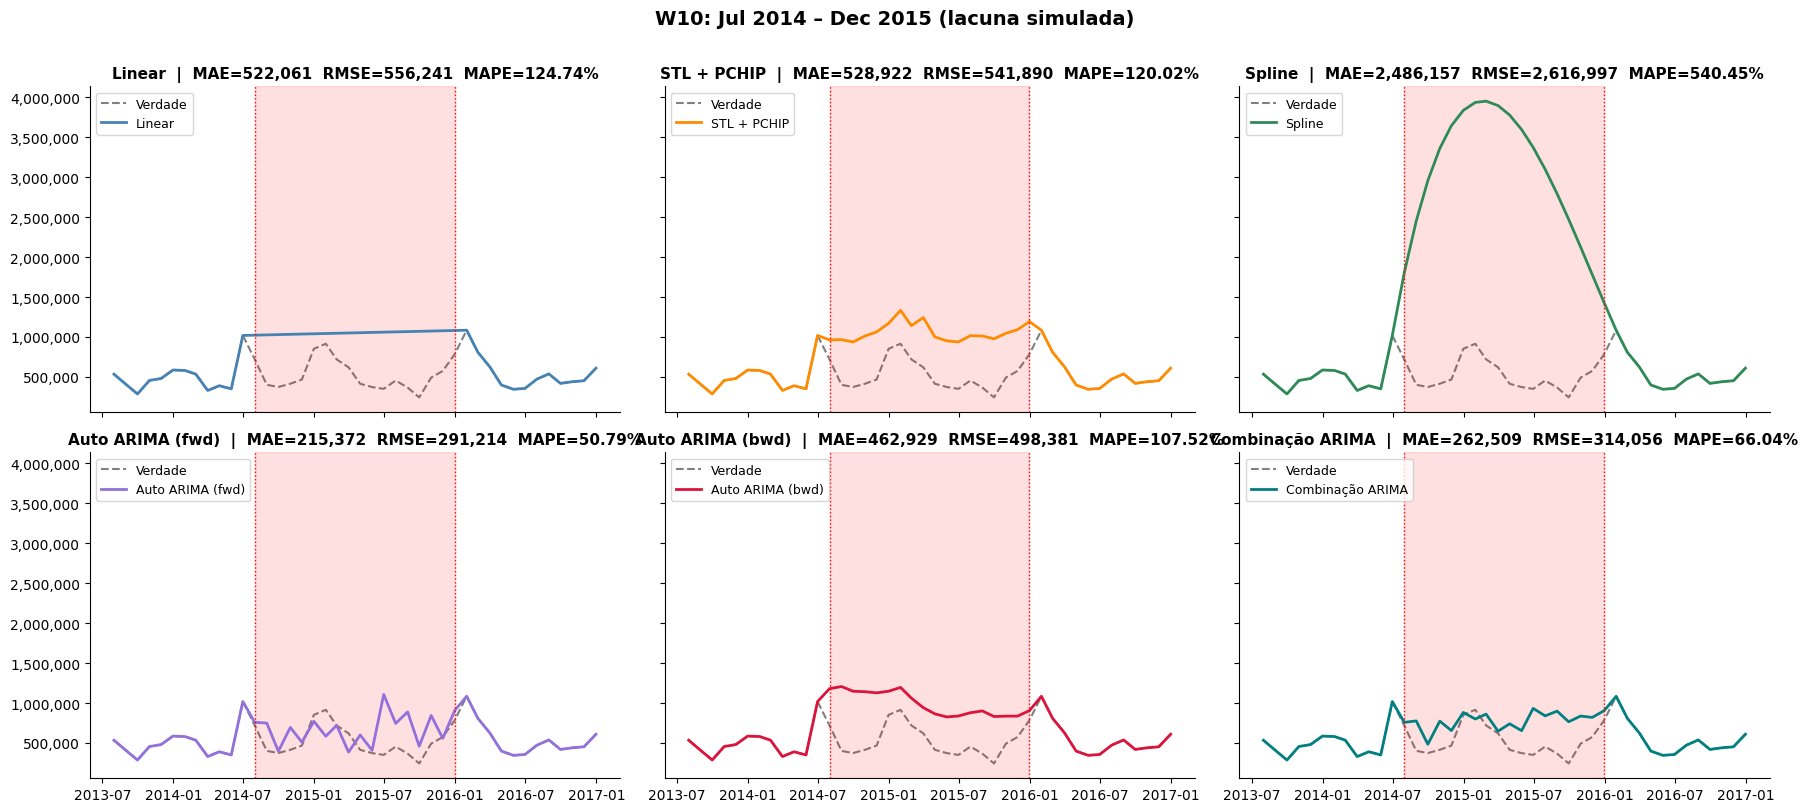

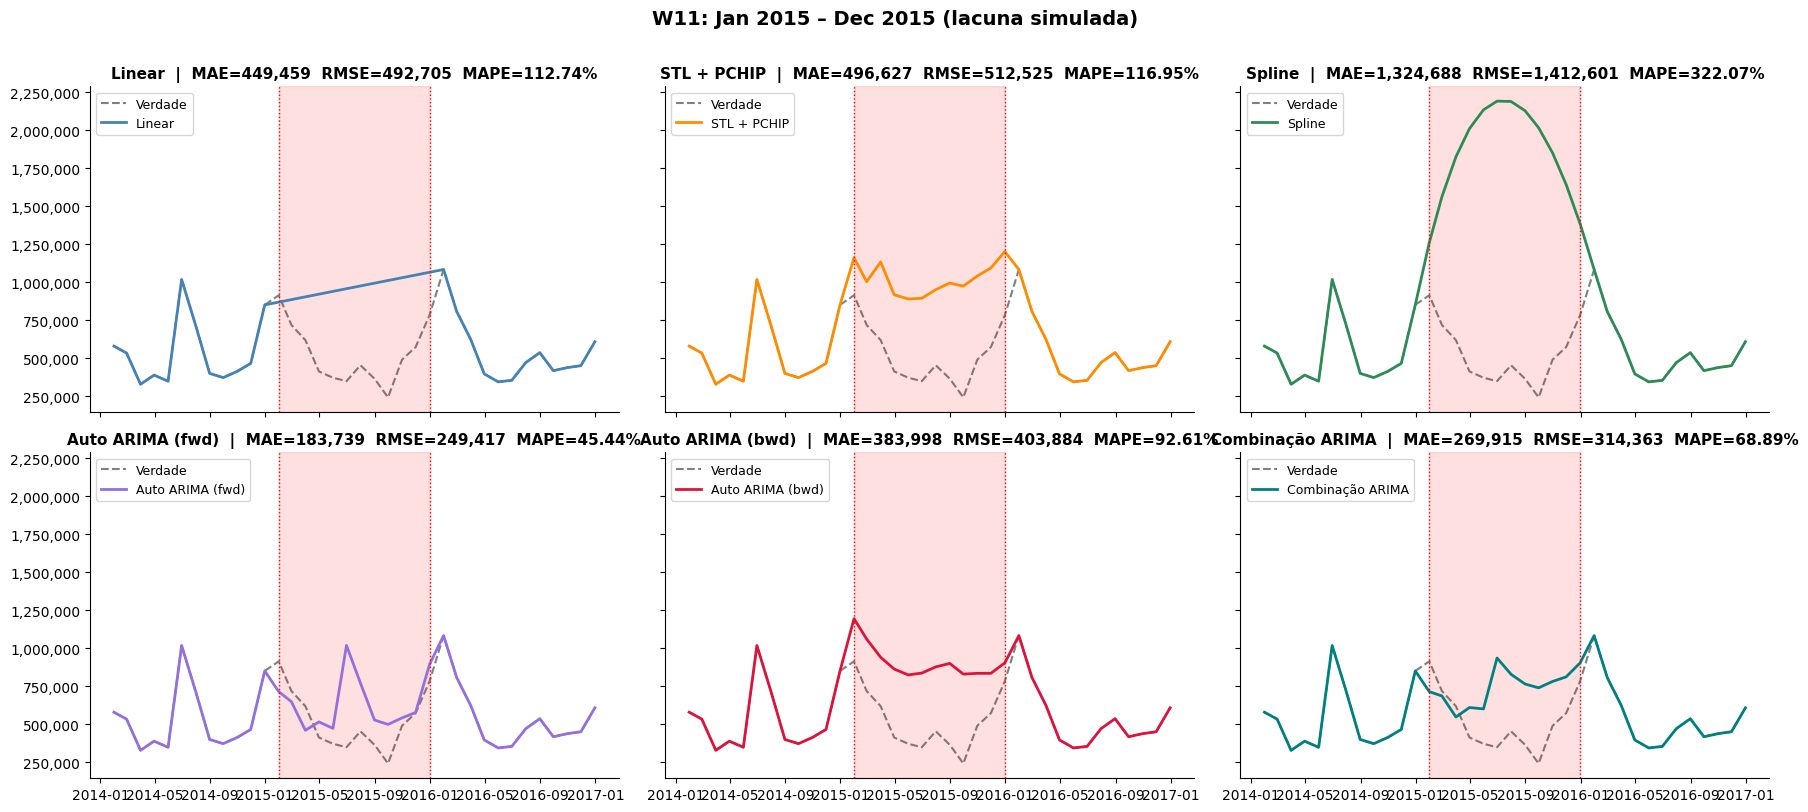

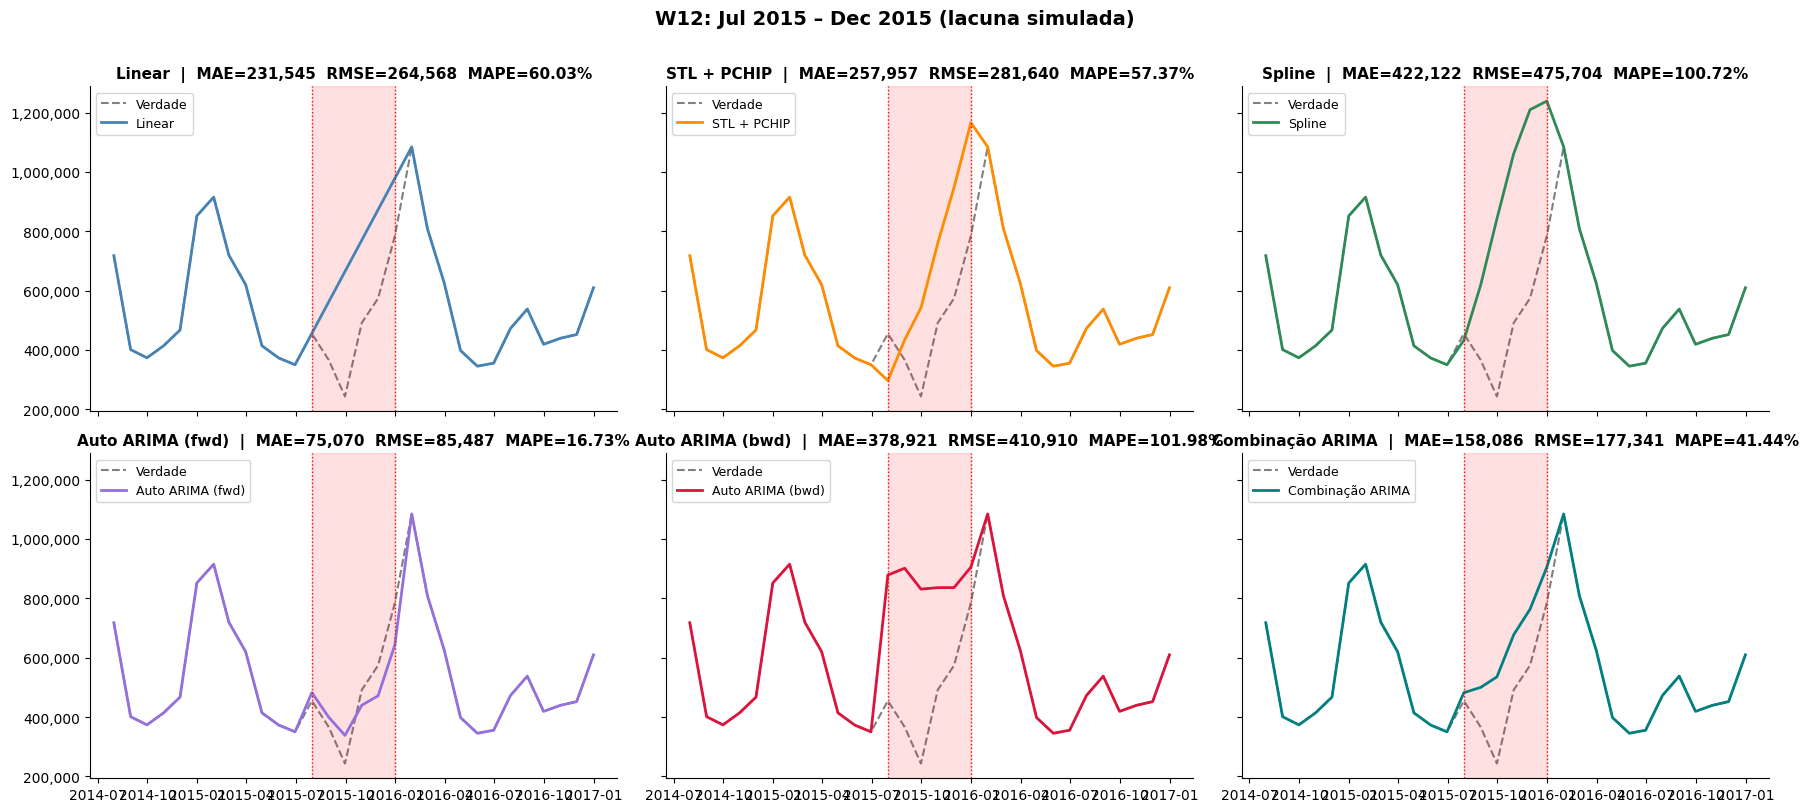

In [6]:
PLOT_BUFFER = pd.DateOffset(months=12)  # contexto mostrado ao redor da lacuna
N_PER_WINDOW_PLOTS = 3  # renderiza apenas as janelas mais recentes

METHODS_TO_PLOT = [
    'Linear',
    'STL + PCHIP',
    'Spline',
    'Auto ARIMA (fwd)',
    'Auto ARIMA (bwd)',
    'Combinação ARIMA',
]

for win_name, gap_start, gap_end in WINDOWS[-N_PER_WINDOW_PLOTS:]:
    res = window_results[win_name]
    gap_mask = res['gap_mask']
    plot_start = gap_start - PLOT_BUFFER
    plot_end = gap_end + PLOT_BUFFER

    fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, method_name in zip(axes, METHODS_TO_PLOT):
        s_imputed = res[method_name]

        # Verdade (ground truth) em cinza tracejado
        ax.plot(
            monthly_df[plot_start:plot_end].index,
            monthly_df.loc[plot_start:plot_end, 'arrival_count'],
            color='gray',
            linewidth=1.5,
            linestyle='--',
            label='Verdade',
            zorder=1,
        )
        # Série imputada
        color, ls = METHOD_STYLES[method_name]
        ax.plot(
            s_imputed[plot_start:plot_end].index,
            s_imputed[plot_start:plot_end],
            color=color,
            linewidth=2,
            linestyle=ls,
            label=method_name,
            zorder=2,
        )
        # Destaque da lacuna
        ax.axvspan(gap_start, gap_end, alpha=0.12, color='red')
        ax.axvline(gap_start, color='red', linestyle=':', linewidth=1)
        ax.axvline(gap_end, color='red', linestyle=':', linewidth=1)

        # Anotação de métricas
        win_metrics = results_df[
            (results_df['Janela'] == win_name) & (results_df['Método'] == method_name)
        ].iloc[0]
        ax.set_title(
            f'{method_name}  |  MAE={win_metrics["MAE"]:,.0f}  '
            f'RMSE={win_metrics["RMSE"]:,.0f}  MAPE={win_metrics["MAPE"]:.2f}%',
            fontsize=11,
            fontweight='bold',
        )
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
        ax.legend(loc='upper left', fontsize=9, frameon=True)
        sns.despine(ax=ax)

    fig.suptitle(
        f'{win_name}: {gap_start.strftime("%b %Y")} – {gap_end.strftime("%b %Y")} (lacuna simulada)',
        fontsize=14,
        fontweight='bold',
        y=1.01,
    )
    plt.tight_layout()
    plt.show()

## Resultados Agregados

In [7]:
summary = (
    results_df
    .groupby('Método')[
        ['MAE', 'RMSE', 'MAPE', 'VarRatio', 'DownstreamRMSE', 'DownstreamMAPE']
    ]
    .mean()
    .round({
        'MAE': 0,
        'RMSE': 0,
        'MAPE': 2,
        'VarRatio': 3,
        'DownstreamRMSE': 0,
        'DownstreamMAPE': 2,
    })
    .sort_values('DownstreamMAPE')
)
summary.index.name = 'Método'
summary.columns = [
    'Média MAE',
    'Média RMSE',
    'Média MAPE (%)',
    'Média var_ratio',
    'Média DS-RMSE',
    'Média DS-MAPE (%)',
]

# Ranking por média de MAPE downstream
summary.insert(0, 'Rank', range(1, len(summary) + 1))

oracle_summary = (
    results_df
    .groupby('Janela')[['OracleRMSE', 'OracleMAPE']]
    .first()
    .round({'OracleRMSE': 0, 'OracleMAPE': 2})
)

print(
    f'\nBenchmark agregado (média em {results_df["Janela"].nunique()} janelas, ordenado por MAPE)'
)
print(
    'var_ratio = var(pred) / var(verdade);  1,0 = ideal,  <1 super-suavizado,  >1 super-espinhoso\n'
)
print(summary.to_string())

print(
    '\nLinha de base oracle por janela (auto-ARIMA ajustado na série real, mesma geometria treino/teste):\n'
)
print(oracle_summary.to_string())
summary


Benchmark agregado (média em 13 janelas, ordenado por MAPE)
var_ratio = var(pred) / var(verdade);  1,0 = ideal,  <1 super-suavizado,  >1 super-espinhoso

                  Rank  Média MAE  Média RMSE  Média MAPE (%)  Média var_ratio  Média DS-RMSE  Média DS-MAPE (%)
Método                                                                                                          
Auto ARIMA (fwd)     1   109768.0    140546.0           26.75            0.526        99237.0              19.60
STL + PCHIP          2   265105.0    286821.0           64.03            1.316       103114.0              20.84
Combinação ARIMA     3   159032.0    184203.0           40.30            0.484       109062.0              21.63
Linear               4   252464.0    285461.0           64.72            0.471       114993.0              22.75
Auto ARIMA (bwd)     5   312016.0    344525.0           77.05            0.610       127721.0              25.62
Spline               6   930967.0   1012507.0         

,Rank,Média MAE,Média RMSE,Média MAPE (%),Média var_ratio,Média DS-RMSE,Média DS-MAPE (%)
Método,,,,,,,
Auto ARIMA (fwd),1,109768.0,140546.0,26.75,0.526,99237.0,19.60
STL + PCHIP,2,265105.0,286821.0,64.03,1.316,103114.0,20.84
Combinação ARIMA,3,159032.0,184203.0,40.30,0.484,109062.0,21.63
Linear,4,252464.0,285461.0,64.72,0.471,114993.0,22.75
Auto ARIMA (bwd),5,312016.0,344525.0,77.05,0.610,127721.0,25.62
Spline,6,930967.0,1012507.0,222.13,7.850,215686.0,43.99


## Gráfico de Comparação de Métodos

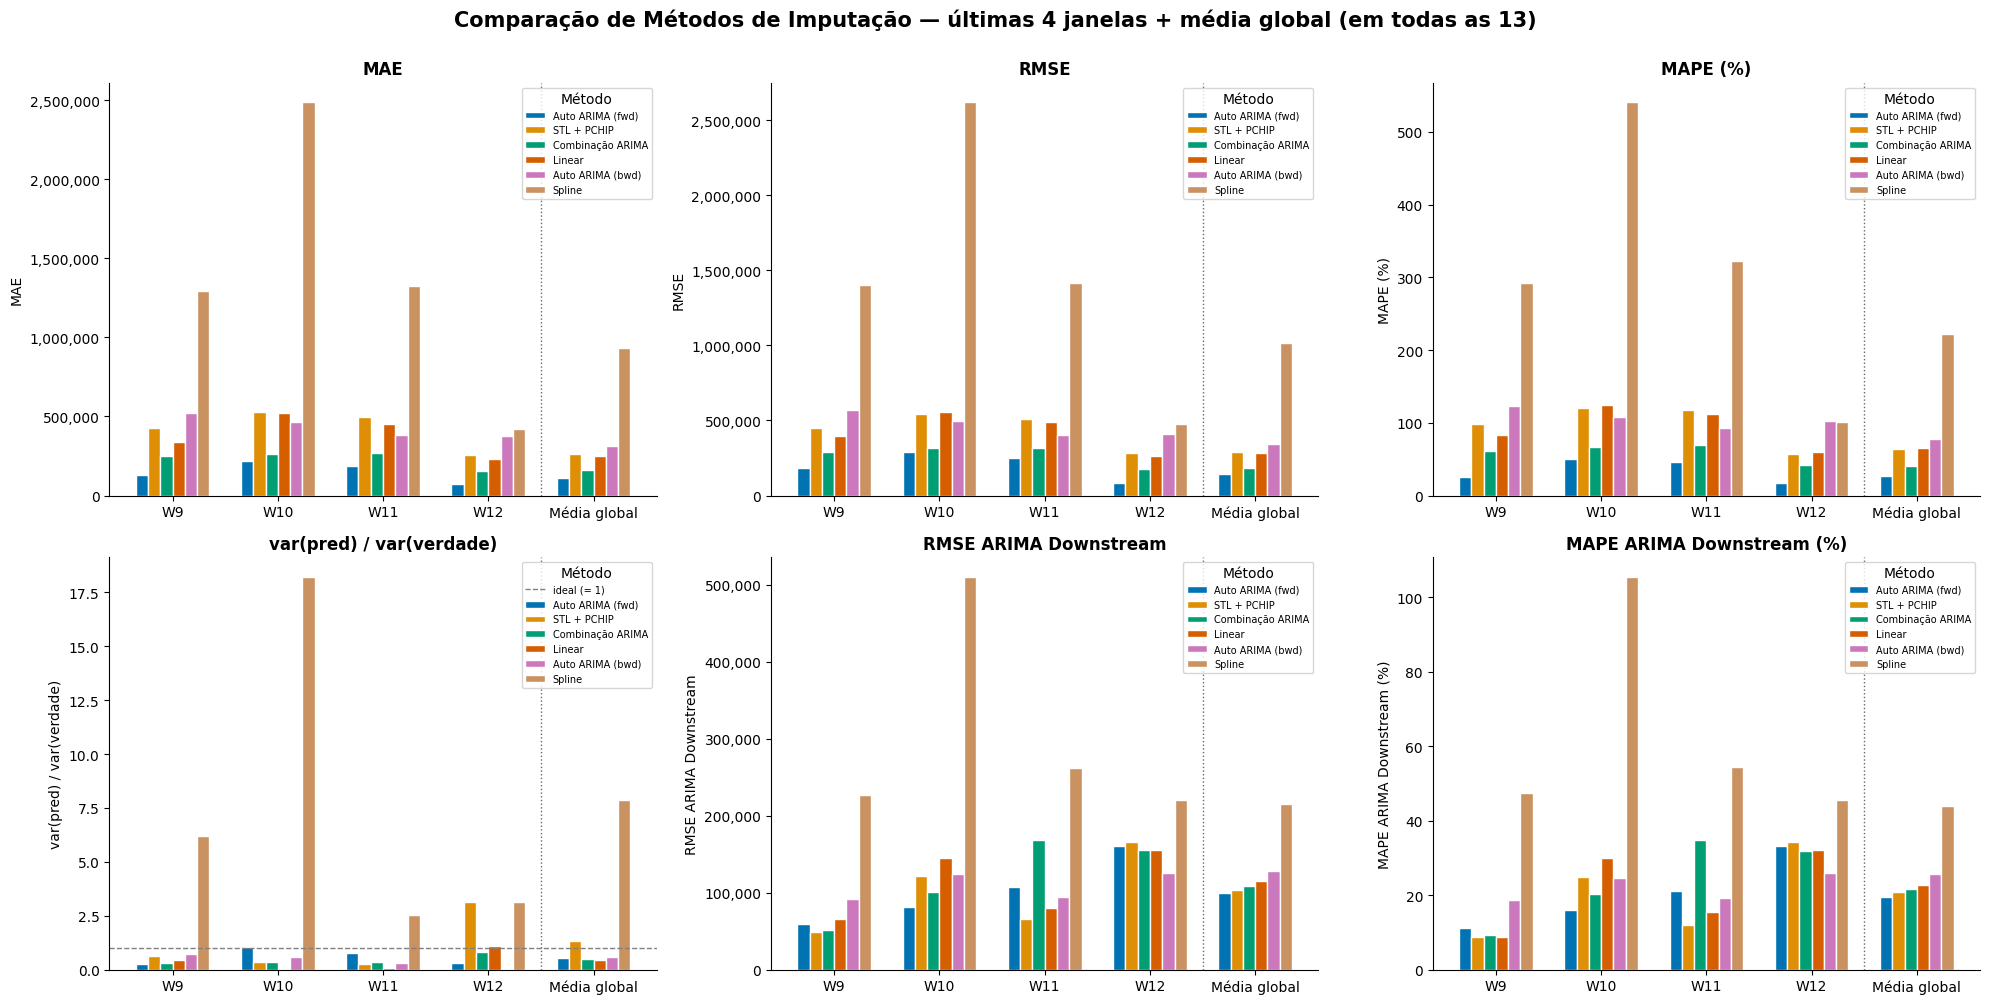

In [8]:
N_CHART_WINDOWS = 4  # janelas mais recentes mostradas ao lado da média global

CHART_METRICS = [
    ('MAE', 'MAE', False, False),
    ('RMSE', 'RMSE', False, False),
    ('MAPE', 'MAPE (%)', True, False),
    ('VarRatio', 'var(pred) / var(verdade)', False, True),
    ('DownstreamRMSE', 'RMSE ARIMA Downstream', False, False),
    ('DownstreamMAPE', 'MAPE ARIMA Downstream (%)', True, False),
]
method_order = summary.index.tolist()  # já ordenado por MAPE médio
window_order = [w[0] for w in WINDOWS]  # ordem cronológica

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for ax, (col, title, is_pct, is_ratio) in zip(axes, CHART_METRICS):
    pivot = results_df.pivot(index='Janela', columns='Método', values=col).reindex(
        window_order
    )[method_order]

    recent = pivot.iloc[-N_CHART_WINDOWS:]
    global_mean = pivot.mean(axis=0, skipna=True).to_frame().T
    global_mean.index = ['Média global']
    to_plot = pd.concat([recent, global_mean])

    to_plot.plot(kind='bar', ax=ax, width=0.7, edgecolor='white')

    # Separa visualmente a barra "Média global" das barras por janela
    ax.axvline(len(recent) - 0.5, color='black', linestyle=':', linewidth=1, alpha=0.6)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Método', fontsize=7, loc='upper right')
    if not is_pct and not is_ratio:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    if is_ratio:
        ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='ideal (= 1)')
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, title='Método', fontsize=7, loc='upper right')
    sns.despine(ax=ax)

fig.suptitle(
    f'Comparação de Métodos de Imputação — últimas {N_CHART_WINDOWS} janelas + média global (em todas as {len(WINDOWS)})',
    fontsize=15,
    fontweight='bold',
    y=1.00,
)
plt.tight_layout()
plt.show()

## Conclusão

A tabela acima classifica os seis métodos pelo MAPE médio nas treze janelas simuladas. O método com melhor desempenho — menor rank — é a escolha recomendada para imputar a lacuna da COVID-19 (2020-01 → 2021-12) no conjunto de dados final.

O cluster W7–W12 (seis janelas terminando em 2015-12-31 com comprimentos de 36m → 6m) também é útil para inspecionar isoladamente: como o contexto ao redor é idêntico, as diferenças nesse cluster isolam como a acurácia de cada método piora com o comprimento da lacuna.

## Teste Simples com Dados da Pandemia

Aplica cada método de imputação baseado em ARIMA à lacuna real da COVID (2020-01 → 2021-12), depois usa a série completamente imputada para prever o ano de **2024** e compara com os valores reais de 2024.

Para cada método:
1. Mascarar 2020-01 → 2021-12 e imputar (forward / backward / combinação).
2. Ajustar um auto-ARIMA na série imputada de 2015-01-01 até 2023-12-31.
3. Prever 12 meses → pontuar contra os valores reais de 2024.

Uma **linha de base oracle** (auto-ARIMA ajustado na mesma janela de treino mas com os valores *reais* da COVID) é incluída como limite superior de acurácia alcançável.

In [9]:
FORECAST_TRAIN_START = pd.Timestamp('2010-01-01')
FORECAST_TRAIN_END = pd.Timestamp('2023-12-31')
FORECAST_TEST_START = pd.Timestamp('2024-01-31')
FORECAST_TEST_END = pd.Timestamp('2024-12-31')
N_FORECAST = 12

series = monthly_df['arrival_count'].copy()
covid_mask = (series.index >= COVID_START) & (series.index <= COVID_END)

masked_covid = series.copy()
masked_covid[covid_mask] = np.nan

pre_covid_end = series[series.index < COVID_START].index[-1]
post_covid_start = series[series.index > COVID_END].index[0]

# Imputa a lacuna real da COVID com todos os métodos
s_linear_covid = apply_linear(masked_covid)
s_stl_pchip_covid = apply_stl_pchip(masked_covid, covid_mask, pre_covid_end)
s_spline_covid = apply_spline(masked_covid)

s_fwd, fwd_model, forecast_fwd_covid = apply_auto_arima(
    masked_covid, covid_mask, pre_covid_end
)
print(f'Ordem ARIMA forward:  {fwd_model.order} x {fwd_model.seasonal_order}')

s_bwd, bwd_model, forecast_bwd_covid = apply_auto_arima_bwd(
    masked_covid, covid_mask, post_covid_start, FORECAST_TRAIN_END
)
print(f'Ordem ARIMA backward: {bwd_model.order} x {bwd_model.seasonal_order}')

s_blend = apply_arima_blend(
    masked_covid, covid_mask, forecast_fwd_covid, forecast_bwd_covid
)

imputed_variants = {
    'Linear': s_linear_covid,
    'STL + PCHIP': s_stl_pchip_covid,
    'Spline': s_spline_covid,
    'Auto ARIMA (fwd)': s_fwd,
    'Auto ARIMA (bwd)': s_bwd,
    'Combinação ARIMA': s_blend,
}

# Verdade real de 2024
y_test = series.loc[FORECAST_TEST_START:FORECAST_TEST_END]
assert len(y_test) == N_FORECAST, (
    f'Esperados {N_FORECAST} meses de teste, obtidos {len(y_test)}'
)

# Oracle: valores reais da COVID + auto-ARIMA treinado até 2023-12-31
oracle_train = series.loc[FORECAST_TRAIN_START:FORECAST_TRAIN_END]
oracle_forecast = _fit_predict_auto_arima(oracle_train.values, N_FORECAST)
oracle_rmse_2024 = rmse(y_test.values, oracle_forecast)
oracle_mape_2024 = mape(y_test.values, oracle_forecast)
print(
    f'\nOracle (valores reais da COVID)  RMSE={oracle_rmse_2024:>10,.0f}  '
    f'MAPE={oracle_mape_2024:>6.2f}%'
)

forecast_records = []
forecasts_2024 = {'Oracle': pd.Series(oracle_forecast, index=y_test.index)}

print(f'\n  {"Método":<20}  {"RMSE":>10}  {"MAPE":>8}')
for method_name, s_imputed in imputed_variants.items():
    train = s_imputed.loc[FORECAST_TRAIN_START:FORECAST_TRAIN_END]
    forecast = _fit_predict_auto_arima(train.values, N_FORECAST)
    forecast = np.clip(forecast, 0, None)

    r = rmse(y_test.values, forecast)
    m = mape(y_test.values, forecast)
    forecast_records.append({'Método': method_name, 'RMSE': r, 'MAPE': m})
    forecasts_2024[method_name] = pd.Series(forecast, index=y_test.index)
    print(f'  {method_name:<20}  {r:>10,.0f}  {m:>7.2f}%')

forecast_results_df = (
    pd.DataFrame(forecast_records).set_index('Método').round({'RMSE': 0, 'MAPE': 2})
)
forecast_results_df

Ordem ARIMA forward:  (2, 1, 2) x (1, 0, 0, 12)
Ordem ARIMA backward: (0, 1, 0) x (1, 0, 0, 12)

Oracle (valores reais da COVID)  RMSE=   110,632  MAPE= 18.19%

  Método                      RMSE      MAPE
  Linear                   156,273    17.73%
  STL + PCHIP              129,427    14.82%
  Spline                   130,731    20.77%
  Auto ARIMA (fwd)         142,729    15.70%
  Auto ARIMA (bwd)         127,764    19.96%
  Combinação ARIMA         134,081    19.61%


,RMSE,MAPE
Método,,
Linear,156273.0,17.73
STL + PCHIP,129427.0,14.82
Spline,130731.0,20.77
Auto ARIMA (fwd),142729.0,15.70
Auto ARIMA (bwd),127764.0,19.96
Combinação ARIMA,134081.0,19.61


Período de treino pós-COVID: 2022-01-31 → 2023-12-31 (24 meses)

Somente pós-COVID (sem imputação)   RMSE=   102,880  MAPE= 11.78%


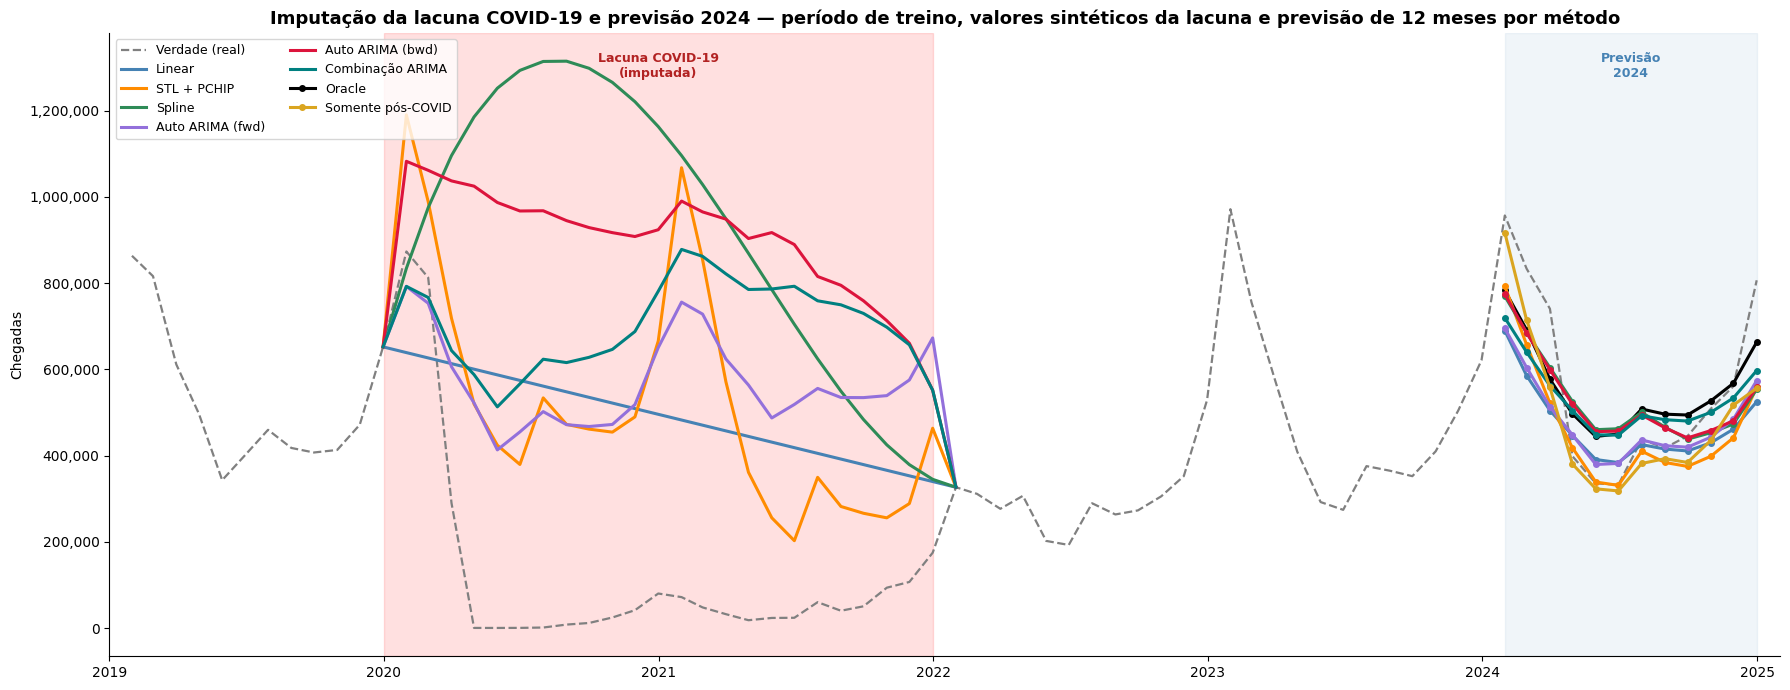

,RMSE,MAPE
Método,,
Somente pós-COVID,102880.0,11.78
STL + PCHIP,129427.0,14.82
Auto ARIMA (fwd),142729.0,15.70
Linear,156273.0,17.73
Combinação ARIMA,134081.0,19.61
Auto ARIMA (bwd),127764.0,19.96
Spline,130731.0,20.77


In [10]:
POST_COVID_TRAIN_START = pd.Timestamp('2022-01-01')

post_covid_train = series.loc[POST_COVID_TRAIN_START:FORECAST_TRAIN_END]
print(
    f'Período de treino pós-COVID: {post_covid_train.index.min().date()} → '
    f'{post_covid_train.index.max().date()} ({len(post_covid_train)} meses)'
)

post_covid_forecast = _fit_predict_auto_arima(post_covid_train.values, N_FORECAST)
post_covid_forecast = np.clip(post_covid_forecast, 0, None)

post_covid_rmse = rmse(y_test.values, post_covid_forecast)
post_covid_mape = mape(y_test.values, post_covid_forecast)
print(
    f'\nSomente pós-COVID (sem imputação)   RMSE={post_covid_rmse:>10,.0f}  '
    f'MAPE={post_covid_mape:>6.2f}%'
)

forecasts_2024['Somente pós-COVID'] = pd.Series(post_covid_forecast, index=y_test.index)
forecast_results_df.loc['Somente pós-COVID'] = [
    round(post_covid_rmse),
    round(post_covid_mape, 2),
]

# Gráfico único: período de treino (a partir de 2019) + imputações da lacuna COVID-19 + previsão 2024
PLOT_START = pd.Timestamp('2019-01-01')

forecast_styles_ext = {
    'Oracle': ('black', '-'),
    'Linear': METHOD_STYLES['Linear'],
    'STL + PCHIP': METHOD_STYLES['STL + PCHIP'],
    'Spline': METHOD_STYLES['Spline'],
    'Auto ARIMA (fwd)': METHOD_STYLES['Auto ARIMA (fwd)'],
    'Auto ARIMA (bwd)': METHOD_STYLES['Auto ARIMA (bwd)'],
    'Combinação ARIMA': METHOD_STYLES['Combinação ARIMA'],
    'Somente pós-COVID': ('goldenrod', '-'),
}

fig, ax = plt.subplots(figsize=(18, 7))

ax.axvspan(COVID_START, COVID_END, alpha=0.12, color='red', zorder=0)
ax.axvspan(
    FORECAST_TEST_START, FORECAST_TEST_END, alpha=0.08, color='steelblue', zorder=0
)

trans = ax.get_xaxis_transform()
ax.text(
    COVID_START + (COVID_END - COVID_START) / 2,
    0.97,
    'Lacuna COVID-19\n(imputada)',
    transform=trans,
    ha='center',
    va='top',
    fontsize=9,
    color='firebrick',
    fontweight='bold',
)
ax.text(
    FORECAST_TEST_START + (FORECAST_TEST_END - FORECAST_TEST_START) / 2,
    0.97,
    'Previsão\n2024',
    transform=trans,
    ha='center',
    va='top',
    fontsize=9,
    color='steelblue',
    fontweight='bold',
)

# Verdade
real = series.loc[PLOT_START:FORECAST_TEST_END]
ax.plot(
    real.index,
    real.values,
    color='gray',
    linewidth=1.6,
    linestyle='--',
    label='Verdade (real)',
    zorder=2,
)

# Curvas de imputação sobre a lacuna COVID (âncoras em cada lado para continuidade visual)
for method_name, s_imputed in imputed_variants.items():
    color, ls = METHOD_STYLES[method_name]
    seg = s_imputed.loc[pre_covid_end:post_covid_start]
    ax.plot(
        seg.index,
        seg.values,
        color=color,
        linewidth=2.2,
        linestyle=ls,
        label=method_name,
        zorder=3,
    )

# Previsão 2024 por método
for name, fc in forecasts_2024.items():
    color, ls = forecast_styles_ext[name]
    label = None if name in imputed_variants else name
    ax.plot(
        fc.index,
        fc.values,
        color=color,
        linewidth=2.2,
        linestyle=ls,
        marker='o',
        markersize=4,
        label=label,
        zorder=3,
    )

ax.set_title(
    'Imputação da lacuna COVID-19 e previsão 2024 — período de treino, '
    'valores sintéticos da lacuna e previsão de 12 meses por método',
    fontsize=13,
    fontweight='bold',
)
ax.set_xlabel('')
ax.set_ylabel('Chegadas')
ax.set_xlim(PLOT_START, FORECAST_TEST_END + pd.DateOffset(months=1))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(loc='upper left', fontsize=9, frameon=True, ncol=2)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

forecast_results_df.sort_values('MAPE')